# 04 — Discrete Fourier Transform, FFT, Frequency Bins, and Leakage

## Learning goals

- Implement the transparent sine-cosine DFT loop.
- Compare manual coefficients with `np.fft`.
- Understand frequency resolution, Nyquist frequency, and bins.
- See spectral leakage when a sinusoid does not land exactly on a bin.
- See why the FFT matters computationally.

## Mental model

The DFT tries a fixed set of candidate waves. The frequency bins are the notes available on the instrument. If your signal's note sits between two keys, energy leaks into neighboring keys.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Build a sampled signal

For $N$ samples spanning $T$ seconds:

- sampling rate: $R=N/T$;
- frequency resolution: $\Delta f = 1/T$;
- Nyquist frequency: $R/2$.

N = 1024
R = 1024 samples/s
T = 1.0 s
frequency resolution Δf = 1/T = 1.0 Hz
Nyquist frequency = R/2 = 512.0 Hz


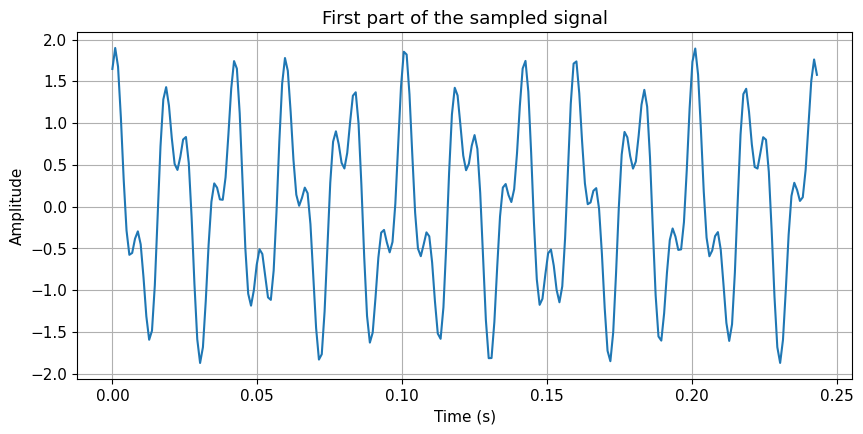

In [2]:
R = 1024
T = 1.0
N = int(R*T)
t = np.arange(N)/R

x = 1.2*np.cos(2*np.pi*50*t - 0.3) + 0.7*np.sin(2*np.pi*120*t + 0.8)

print(f"N = {N}")
print(f"R = {R} samples/s")
print(f"T = {T} s")
print(f"frequency resolution Δf = 1/T = {1/T} Hz")
print(f"Nyquist frequency = R/2 = {R/2} Hz")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t[:250], x[:250])
ax.set_title("First part of the sampled signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
plt.show()

## A transparent sine-cosine DFT loop

This mirrors the book's pedagogical implementation: multiply by candidate cosine and sine waves, then average.

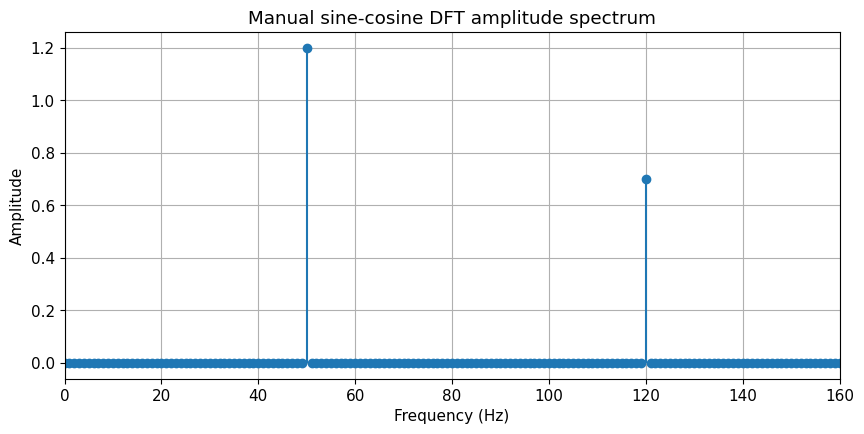

In [3]:
def real_dft_coefficients(x, R, fmax=None):
    x = np.asarray(x)
    N = len(x)
    T = N/R
    if fmax is None:
        fmax = R/2
    nmax = int(np.floor(fmax*T))
    t = np.arange(N)/R
    freqs = np.arange(nmax+1)/T
    C = np.zeros(nmax+1)
    D = np.zeros(nmax+1)
    C[0] = 2*np.mean(x)
    for n in range(1, nmax+1):
        C[n] = 2*np.mean(x*np.cos(2*np.pi*freqs[n]*t))
        D[n] = 2*np.mean(x*np.sin(2*np.pi*freqs[n]*t))
    A = np.hypot(C, D)
    return freqs, C, D, A

freqs_loop, C_loop, D_loop, A_loop = real_dft_coefficients(x, R, fmax=200)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.stem(freqs_loop, A_loop, basefmt=" ")
ax.set_xlim(0, 160)
ax.set_title("Manual sine-cosine DFT amplitude spectrum")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
plt.show()

## Compare with `np.fft.rfft`

For NumPy's FFT convention, the real coefficients relate to the complex coefficients by

$$C_n = \frac{2\operatorname{Re}(X_n)}{N}, \qquad D_n = -\frac{2\operatorname{Im}(X_n)}{N}.$$

Maximum amplitude-spectrum difference up to 200 Hz: 7.151587223044455e-15


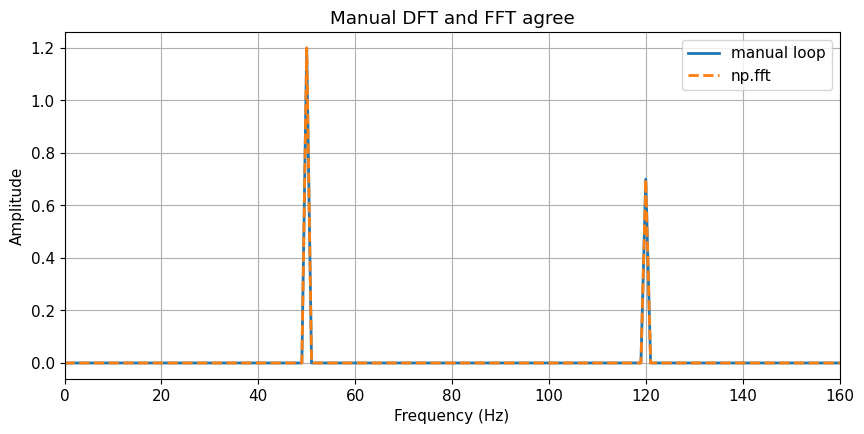

In [4]:
X = np.fft.rfft(x)
freqs_fft = np.fft.rfftfreq(N, d=1/R)
C_fft = 2*np.real(X)/N
D_fft = -2*np.imag(X)/N
C_fft[0] = 2*np.real(X[0])/N
D_fft[0] = 0
A_fft = np.hypot(C_fft, D_fft)

mask = freqs_fft <= 200
max_amp_diff = np.max(np.abs(A_fft[mask] - A_loop[:mask.sum()]))
print("Maximum amplitude-spectrum difference up to 200 Hz:", max_amp_diff)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(freqs_loop, A_loop, label="manual loop", linewidth=2)
ax.plot(freqs_fft[mask], A_fft[mask], "--", label="np.fft", linewidth=2)
ax.set_xlim(0, 160)
ax.set_title("Manual DFT and FFT agree")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

## Spectral leakage

If the signal frequency is exactly one of the DFT bins, the spectrum is sharp. If it falls between bins, the DFT cannot represent it with one bin, so energy spreads out.

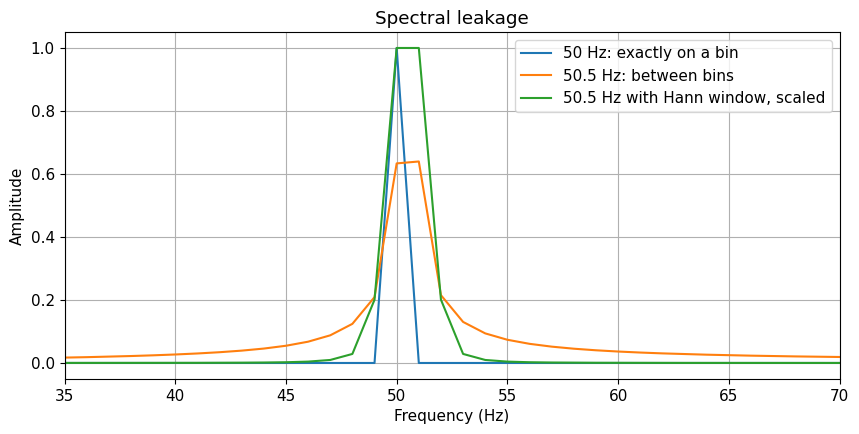

In [5]:
def amplitude_spectrum(signal, R):
    N = len(signal)
    X = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(N, d=1/R)
    A = 2*np.abs(X)/N
    A[0] = np.abs(X[0])/N
    return freqs, A

on_bin = np.cos(2*np.pi*50*t)
off_bin = np.cos(2*np.pi*50.5*t)
window = np.hanning(N)
off_bin_windowed = off_bin * window

f_on, A_on = amplitude_spectrum(on_bin, R)
f_off, A_off = amplitude_spectrum(off_bin, R)
f_win, A_win = amplitude_spectrum(off_bin_windowed, R)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(f_on, A_on, label="50 Hz: exactly on a bin")
ax.plot(f_off, A_off, label="50.5 Hz: between bins")
ax.plot(f_win, A_win/A_win.max(), label="50.5 Hz with Hann window, scaled")
ax.set_xlim(35, 70)
ax.set_title("Spectral leakage")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

## Why the FFT changed everything

A direct DFT scales like $O(N^2)$. The FFT scales like $O(N\log N)$.

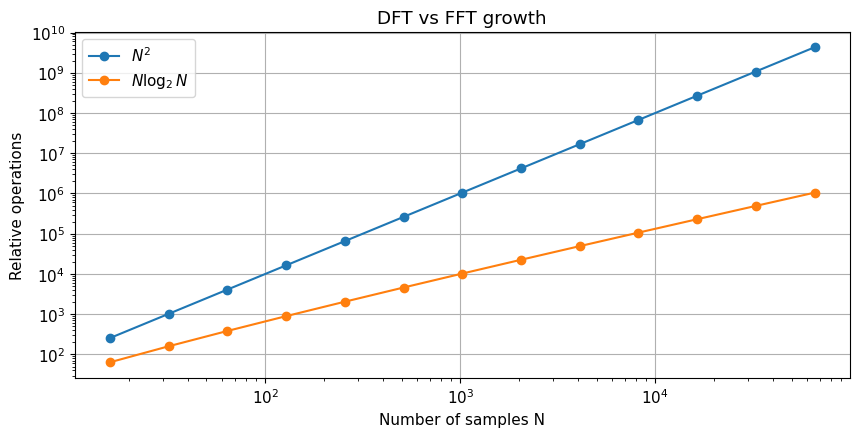

N=  1024: N^2 / (N log2 N) ≈ 102x
N=  4096: N^2 / (N log2 N) ≈ 341x
N= 65536: N^2 / (N log2 N) ≈ 4096x


In [6]:
Ns = 2**np.arange(4, 17)
ops_dft = Ns**2
ops_fft = Ns*np.log2(Ns)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(Ns, ops_dft, marker="o", label=r"$N^2$")
ax.plot(Ns, ops_fft, marker="o", label=r"$N\log_2 N$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("DFT vs FFT growth")
ax.set_xlabel("Number of samples N")
ax.set_ylabel("Relative operations")
ax.legend()
plt.show()

for Ntest in [1024, 4096, 65536]:
    print(f"N={Ntest:6d}: N^2 / (N log2 N) ≈ {Ntest**2/(Ntest*np.log2(Ntest)):.0f}x")

## Checkpoint

1. Change `T` to 2 seconds while keeping `R` fixed. What happens to frequency resolution?
2. Change the off-bin frequency from 50.5 Hz to 50.25 Hz. How does leakage change?
3. Why does a window reduce sidelobes but also broaden the main peak?